In [1]:
from tensor_product_space import TensorProductSpace, UnivariateSplineSpace
from hierarchical_mesh import HierarchicalMesh
import numpy as np
import scipy.sparse as sp
from cartesian_mesh import CartesianMesh
from hierarchical_space import HierarchicalSpace

In [2]:
def refine(knots: np.ndarray, p: int, n_times: int=1)->np.ndarray:
    """Given `knots`, returns its dyadic refinement with multiplicity `p+1`
    at the extremities."""
    knots = np.asarray(knots)
    mult_left = np.searchsorted(knots, knots[0], side='right')
    mult_right = len(knots) - np.searchsorted(knots, knots[-1], side='left')
    pad_left = max(0, p + 1 - mult_left)
    pad_right = max(0, p + 1 - mult_right)
    if pad_left > 0 or pad_right > 0:
        knots = np.concatenate((
            np.full(pad_left, knots[0], dtype=knots.dtype),
            knots,
            np.full(pad_right, knots[-1], dtype=knots.dtype)
        ))
    if n_times == 0:
        return knots
    
    # Find indices where the knot value changes
    jump_idx = np.where(knots[1:] > knots[:-1])[0]
    left_vals = knots[jump_idx]
    right_vals =knots[jump_idx + 1]
    num_new_points = (1<<n_times)-1
    fractions = np.linspace(0.,1.,num_new_points+2)[1:-1]
    new_points = left_vals[:, None] + (right_vals - left_vals)[:, None] * fractions[None, :]
    new_points = new_points.ravel()
    insert_positions = np.repeat(jump_idx + 1, num_new_points)
    
    return np.insert(knots, insert_positions, new_points)
        

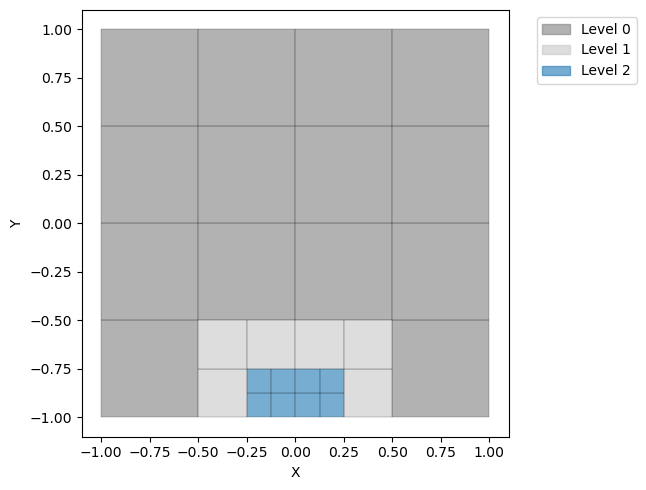

In [3]:
p=2
m=3
knots1 = np.array([-1, 0,0, 1.], dtype=float)
knots2 = refine(knots1, p, n_times=1)
hs = HierarchicalSpace([knots2, knots2], [p])
hs.refine([4,8], 0, refine_T_neighbours=True, m=m)
hs.refine_in_rectangle(np.array([[-0.25,0.25], [-1, -0.75]]), refine_T_neighbours=True, m=m, level=1)
#hs.refine_in_rectangle(np.array([[-0.25, 0.25], [0., 0.5]]), 2, refine_T_neighbours=True, m=m)
#hs.refine_in_rectangle(np.array([[-0.5, 0], [0, 0.25]]), 2, refine_T_neighbours=True, m=m)
#hs.refine_in_rectangle(np.array([[0.,.5], [-1., -0.5]]), 0, refine_T_neighbours=True, m=m)
#hs.refine_in_rectangles([np.array([[0.25, .5], [-1, -0.75]])], 1, refine_T_neighbours=True, m=m)
hs.hmesh.plot_cells()

In [4]:
hs.hmesh.aelem_level

{0: array([ 0,  1,  2,  3,  5,  6,  7,  9, 10, 11, 12, 13, 14, 15],
       dtype=int32),
 1: array([16, 17, 25, 33, 40, 41], dtype=int32),
 2: array([ 96,  97, 112, 113, 128, 129, 144, 145], dtype=int32)}

In [5]:
# hs.hmesh.get_cell_midpoint(hs.hmesh.aelem_level[0], 0, True)

In [6]:
for l in range(hs.nlevels):
    ops = hs.local_multi_level_extraction_operator3(element_indices=hs.hmesh.aelem_level[l], element_level=l, l=l, vectorised=True)
    ops2 = hs.local_multi_level_extraction_operator3(element_indices=hs.hmesh.aelem_level[l], element_level=l, l=l, vectorised=False)
    for i, op in enumerate(ops):
        sum = np.sum(op, axis=0)
        if not np.allclose(sum, np.ones_like(sum)) or not np.allclose(op, ops2[i]):
            print(f"Wrong for l={l}")

In [7]:
hs.truly_active

{0: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
        35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48],
       dtype=int32),
 1: array([44, 45, 56, 66, 67], dtype=int32),
 2: array([152, 153, 171, 172, 190, 191], dtype=int32)}

In [8]:
from copy import deepcopy

funcs_truncated_support = {}
for l in range(hs.nlevels):
    for func in hs.truly_active[l]:
        same_level_support = hs.level_spaces[l].basis_to_cell(func)
        active_cells = np.intersect1d(same_level_support, hs.hmesh.aelem_level[l])
        inactive_cells = np.setdiff1d(same_level_support, hs.hmesh.aelem_level[l])
        funcs_truncated_support[(l, int(func))] = [(l, active_cells)]
        if inactive_cells.size==0:
            continue
        funcs_to_check = deepcopy(func)
        
        for ll in range(l+1, hs.nlevels):
            children_funcs = np.unique(np.concatenate(hs.level_spaces[ll-1].get_children_functions(funcs_to_check)))
            kept_children = []
            for idx, children in enumerate(children_funcs):
                mask = ~np.isin(children, hs.truly_active[ll])
                if not np.any(mask):
                    continue
                kept_children.append(children[mask])
            if len(kept_children)==0:
                continue
            
            kept_children = np.unique(kept_children)
          
            cells = np.intersect1d(hs.hmesh.aelem_level[ll], 
                                   np.concatenate(hs.level_spaces[ll].basis_to_cell(kept_children)))
            
            if cells.size==0:
                continue
            funcs_truncated_support[(l, int(func))].append((ll, cells))
            funcs_to_check = kept_children



In [9]:
funcs_truncated_support

{(0, 0): [(0, array([0], dtype=int32))],
 (0, 1): [(0, array([0, 1], dtype=int32))],
 (0, 2): [(0, array([0, 1], dtype=int32))],
 (0, 3): [(0, array([1, 2], dtype=int32))],
 (0, 4): [(0, array([2, 3], dtype=int32))],
 (0, 5): [(0, array([2, 3], dtype=int32))],
 (0, 6): [(0, array([3], dtype=int32))],
 (0, 7): [(0, array([0], dtype=int32)),
  (1, array([16, 17, 25], dtype=int32)),
  (2, array([ 96,  97, 112, 113], dtype=int32))],
 (0, 8): [(0, array([0, 1, 5], dtype=int32)),
  (1, array([16, 17, 25], dtype=int32)),
  (2, array([ 96,  97, 112, 113], dtype=int32))],
 (0, 9): [(0, array([0, 1, 5], dtype=int32)),
  (1, array([16, 17, 25], dtype=int32)),
  (2, array([ 96,  97, 112, 113], dtype=int32))],
 (0, 10): [(0, array([1, 2, 5, 6], dtype=int32))],
 (0, 11): [(0, array([2, 3, 6, 7], dtype=int32))],
 (0, 12): [(0, array([2, 3, 6, 7], dtype=int32))],
 (0, 13): [(0, array([3, 7], dtype=int32))],
 (0, 14): [(0, array([0], dtype=int32)),
  (1, array([16, 17, 25], dtype=int32)),
  (2, array([

In [10]:
edges = []
prime_numbers = [2,3,5,7,11,13,17,19,23,29]
count=0
cell_dict = {}
for i in range(hs.nlevels):
    for j in hs.hmesh.aelem_level[i]:
        cell_dict[(i, j)] = count
        count +=1

for idx, vertex in enumerate(funcs_truncated_support.values()):
    to_add = []
    for stuff in vertex:
        lvl = stuff[0]
        cell_indices = stuff[1]
        # if len(cell_indices)<2:
        #     continue
        for cell_index in cell_indices:
            to_add.append(cell_dict[lvl, int(cell_index)])
            #to_add.append(prime_numbers[lvl+1]*(int(cell_index)+1))
    if len(to_add)>1:
        edges.append(tuple(to_add))
len(edges)

55

In [11]:
hs.hmesh.nel

28

In [12]:
def output_for_hmetis(hs, edges):
    with open("hmetis.txt", 'w') as file:
        file.write(str(len(edges)))
        file.write(" ")
        file.write(str(hs.hmesh.nel))
        file.write(" 10\n")
        for edge in edges:
            edge = list(edge)
            data_to_write = "".join([str(r+1)+" " for r in edge])
            file.write(data_to_write)
            file.write("\n")
        for i in range(1, hs.hmesh.nel+1):
            if i<=len(hs.hmesh.aelem_level[0]):
                file.write("1\n")
            elif i<=len(hs.hmesh.aelem_level[0])+len(hs.hmesh.aelem_level[1]):
                file.write("2\n")
            else:
                if i<hs.hmesh.nel:
                    file.write("3\n")
                else:
                    file.write("3")
            

output_for_hmetis(hs, edges)

In [44]:
import multiprocessing
import mtkahypar

#mtk = mtkahypar.initialize(multiprocessing.cpu_count())
context = mtk.context_from_preset(mtkahypar.PresetType.DEFAULT)
context.set_partitioning_parameters(
  3,                       # number of blocks
  0.04,                    # imbalance parameter
  mtkahypar.Objective.KM1) # objective function
mtkahypar.set_seed(2026)     # seed
context.logging = True
hypergraph = mtk.hypergraph_from_file("hmetis.txt", context)
partitioned_hg = hypergraph.partition(context)

print("Partition Stats:")
print("Imbalance = " + str(partitioned_hg.imbalance(context)))
print("km1       = " + str(partitioned_hg.km1()))
print("Block Weights:")
for i in partitioned_hg.blocks():
  print(f"Weight of Block {i} = {partitioned_hg.block_weight(i)}")

*******************************************************************************
*                            Partitioning Context                             *
*******************************************************************************
Partitioning Parameters:
  Hypergraph:                         
  Input File Format:                  hMetis (-> hypergraph)
  Preset:                             default
  k:                                  3
  epsilon:                            0.04
  Objective:                          km1
  seed:                               0
  Number of V-Cycles:                 0
  Ignore HE Size Threshold:           1000
  Large HE Size Threshold:            50000
-------------------------------------------------------------------------------
Preprocessing Parameters:
  Use Community Detection:            true
  Disable C. D. for Mesh Graphs:      true

  Community Detection Parameters:
    Edge Weight Function:                uniform
    Maximum Louvain-P

In [43]:
print("\nVertex Assignments:")
# Loop through every vertex ID
for node in range(hypergraph.num_nodes()):
    block = partitioned_hg.block_id(node)
    print(f"Vertex {node} is assigned to Block {block}")


Vertex Assignments:
Vertex 0 is assigned to Block 1
Vertex 1 is assigned to Block 1
Vertex 2 is assigned to Block 1
Vertex 3 is assigned to Block 1
Vertex 4 is assigned to Block 1
Vertex 5 is assigned to Block 1
Vertex 6 is assigned to Block 1
Vertex 7 is assigned to Block 3
Vertex 8 is assigned to Block 3
Vertex 9 is assigned to Block 3
Vertex 10 is assigned to Block 3
Vertex 11 is assigned to Block 3
Vertex 12 is assigned to Block 3
Vertex 13 is assigned to Block 3
Vertex 14 is assigned to Block 1
Vertex 15 is assigned to Block 1
Vertex 16 is assigned to Block 1
Vertex 17 is assigned to Block 3
Vertex 18 is assigned to Block 3
Vertex 19 is assigned to Block 3
Vertex 20 is assigned to Block 0
Vertex 21 is assigned to Block 0
Vertex 22 is assigned to Block 0
Vertex 23 is assigned to Block 0
Vertex 24 is assigned to Block 2
Vertex 25 is assigned to Block 2
Vertex 26 is assigned to Block 2
Vertex 27 is assigned to Block 2


In [ ]:
funcs_truncated_support = {}
for l in range(hs.nlevels):
    for func in hs.truly_active[l]:
        same_level_support = hs.level_spaces[l].basis_to_cell(func)
        active_cells = np.intersect1d(same_level_support, hs.hmesh.aelem_level[l])
        funcs_truncated_support[(l, int(func))] = [(l, active_cells)]
        inactive_cells = np.setdiff1d(same_level_support, active_cells)
        if inactive_cells.size==0:
            continue
        for ll in range(l+1, min(hs.nlevels, l+m)):
            try:
                _, children_cells = hs.hmesh.get_children(level=ll-1, marked_cells_at_level=inactive_cells)
            except TypeError:
                print('oh, no')
                
            active_cells = np.intersect1d(children_cells, hs.hmesh.aelem_level[ll])
            inactive_cells = np.setdiff1d(children_cells, active_cells)
            to_add = []
            if active_cells.size==0:
                continue
            for cell in active_cells:
                extended_support = hs.level_spaces[ll].get_support_extension(cell)
                parents = hs.hmesh.get_parent_at_level(start_level=ll, stop_level=l, 
                                                       marked_cells_at_start_level=extended_support)
                active_parents = np.intersect1d(parents, hs.hmesh.aelem_level[l])
                if active_parents.size>0:
                    try:
                        to_add.append(cell)
                    except IndexError:
                        print('nooo')
            pass #idx, e_s in enumerate(...)
                     
            funcs_truncated_support[(l, int(func))].extend((ll, np.array(to_add)))
        pass # ll in range(l+1, hs.nlevels)
    pass # func in hs.truly_active[l]
pass #l in range(hs.nlevles)

In [ ]:
funcs_truncated_support

{(0, 0): [(0, array([0], dtype=int32))],
 (0, 1): [(0, array([0, 1], dtype=int32))],
 (0, 2): [(0, array([0, 1], dtype=int32)), 1, array([4, 5], dtype=int32)],
 (0, 3): [(0, array([1], dtype=int32)),
  1,
  array([4, 5], dtype=int32),
  2,
  array([], dtype=float64)],
 (0, 5): [(0, array([5], dtype=int32)),
  1,
  array([9], dtype=int32),
  2,
  array([], dtype=float64)],
 (0, 6): [(0, array([5, 6], dtype=int32)),
  1,
  array([9], dtype=int32),
  2,
  array([], dtype=float64)],
 (0, 7): [(0, array([5, 6, 7], dtype=int32))],
 (0, 8): [(0, array([6, 7], dtype=int32))],
 (0, 9): [(0, array([7], dtype=int32))],
 (1, 6): [(1, array([4, 5], dtype=int32)), 2, array([12, 13], dtype=int32)],
 (1, 7): [(1, array([5], dtype=int32)), 2, array([12, 13], dtype=int32)],
 (1, 9): [(1, array([9], dtype=int32)), 2, array([16, 17], dtype=int32)],
 (2, 14): [(2, array([12, 13, 14], dtype=int32))],
 (2, 15): [(2, array([13, 14, 15], dtype=int32))],
 (2, 16): [(2, array([14, 15, 16], dtype=int32))],
 (2, 1

In [ ]:
funcs_truncated_support = {}
for l in range(hs.nlevels):
    for func in hs.truly_active[l]:
        same_level_support = hs.level_spaces[l].basis_to_cell(func)
        active_cells = np.intersect1d(same_level_support, hs.hmesh.aelem_level[l])
        funcs_truncated_support[(l, int(func))] = [(l, active_cells)]
        inactive_cells = np.setdiff1d(same_level_support, active_cells)
        if inactive_cells.size==0:
            continue
        for ll in range(l+1, min(hs.nlevels, l+m)):
            try:
                _, children_cells = hs.hmesh.get_children(level=ll-1, marked_cells_at_level=inactive_cells)
            except TypeError:
                print('oh, no')
                
            active_cells = np.intersect1d(children_cells, hs.hmesh.aelem_level[ll])
            inactive_cells = np.setdiff1d(children_cells, active_cells)
            to_add = []
            if active_cells.size==0:
                continue
            for cell in active_cells:
                basis_on_cell = hs.level_spaces[ll].cell_to_basis(cell)
                truly_active_on_cell = np.intersect1d(hs.truly_active[ll], basis_on_cell)
                if len(truly_active_on_cell)<len(basis_on_cell):
                    to_add.append(cell)
                     
            funcs_truncated_support[(l, int(func))].extend((ll, np.array(to_add)))
        pass # ll in range(l+1, hs.nlevels)
    pass # func in hs.truly_active[l]
pass #l in range(hs.nlevles)

In [ ]:
funcs_truncated_support

{(0, 0): [(0, array([0], dtype=int32))],
 (0, 1): [(0, array([0, 1], dtype=int32))],
 (0, 2): [(0, array([0, 1], dtype=int32)), 1, array([4, 5], dtype=int32)],
 (0, 3): [(0, array([1], dtype=int32)),
  1,
  array([4, 5], dtype=int32),
  2,
  array([12, 13], dtype=int32)],
 (0, 5): [(0, array([5], dtype=int32)),
  1,
  array([9], dtype=int32),
  2,
  array([12, 13, 16, 17], dtype=int32)],
 (0, 6): [(0, array([5, 6], dtype=int32)),
  1,
  array([9], dtype=int32),
  2,
  array([16, 17], dtype=int32)],
 (0, 7): [(0, array([5, 6, 7], dtype=int32))],
 (0, 8): [(0, array([6, 7], dtype=int32))],
 (0, 9): [(0, array([7], dtype=int32))],
 (1, 6): [(1, array([4, 5], dtype=int32)), 2, array([12, 13], dtype=int32)],
 (1, 7): [(1, array([5], dtype=int32)), 2, array([12, 13], dtype=int32)],
 (1, 9): [(1, array([9], dtype=int32)), 2, array([16, 17], dtype=int32)],
 (2, 14): [(2, array([12, 13, 14], dtype=int32))],
 (2, 15): [(2, array([13, 14, 15], dtype=int32))],
 (2, 16): [(2, array([14, 15, 16], dt

In [ ]:
thb_ops = []
for l in range(hs.nlevels):
    thb_ops.extend(hs.local_multi_level_extraction_operator2(hs.hmesh.aelem_level[l], l, l))

In [ ]:
for op in thb_ops:
    print(f"{op}\n")

In [ ]:
lvl = 3
trunc_ops = hs.local_multi_level_extraction_operator3(hs.hmesh.aelem_level[lvl], lvl, lvl)
for op in trunc_ops:
    if not np.allclose(np.sum(op, axis=0), np.ones(op.shape[1])):
        print(np.sum(op, axis=0))

In [ ]:
total_cells = 0
total_funcs = 0
funcs_dict = {}
counter = 0
for i in range(hs.nlevels):
    total_cells+=len(hs.hmesh.aelem_level[i])
    total_funcs += len(hs.truly_active[i])
    for func in hs.truly_active[i]:
        funcs_dict[i, func] = counter
        counter+=1


adj_matrix = np.zeros((total_cells, total_funcs), dtype=int)
for lvl in range(hs.nlevels):
    for idx, function in enumerate(hs.truly_active[lvl]):
        candidate_cells = hs.level_spaces[lvl].basis_to_cell(function)
        parents_by_level = {lvl: np.intersect1d(candidate_cells, hs.hmesh.aelem_level[lvl])}
        for lvl2 in range(max(0,lvl-m), lvl): #if mesh is m-admissible, a function can only be supported on cells of m different levels
            parents_by_level[lvl2] = np.intersect1d(hs.hmesh.aelem_level[lvl2], 
                                                    hs.hmesh.get_parent_at_level(start_level=lvl, stop_level=lvl2, 
                                                                                 marked_cells_at_start_level=candidate_cells))
        pass
        for 
        adj_matrix[idx] = 
    pass # found all active cells in the support of given function
            



In [ ]:
adj_matrix

In [ ]:
lvl = 2
opreators3 = hs.local_multi_level_extraction_operator3(element_indices=hs.hmesh.aelem_level[lvl], element_level=lvl, l=lvl)
opreators2 = hs.local_multi_level_extraction_operator2(element_indices=hs.hmesh.aelem_level[lvl], element_level=lvl, l=lvl)

In [ ]:
np.sum(opreators2[9], axis=1)

In [ ]:
for i in range(len(opreators2)):
    if not np.allclose(opreators2[i], opreators3[i]) or not np.allclose(np.sum(opreators3[i], axis=0), np.ones_like(opreators3[i][0])):
        print(False)

In [ ]:
hs.get_all_active_functions_on_cell(cell_idx=14, level=2)

In [ ]:
midpoints0 = hs.level_spaces[0].middle_points(hs.truly_active[0])
midpoints1 = hs.level_spaces[1].middle_points(hs.truly_active[1])

In [ ]:
quantised0 = hs.level_spaces[0].quantisation(midpoints0, k=31)
quantised1 = hs.level_spaces[1].quantisation(midpoints1, k=31)

In [ ]:
quantised = np.vstack((quantised0, quantised1))

In [ ]:
sum([len(active_l) for active_l in hs.truly_active.values()])

In [ ]:
hs.truly_active

In [ ]:
from tensor_product_space import quantised_to_morton

In [ ]:
morton = quantised_to_morton(quantised_midpoints=quantised.astype(np.int64))

In [ ]:
dof_order = np.argsort(morton)

In [ ]:
dof_order

In [ ]:
m=0
truly_active_dict: dict[int, tuple[int, np.int32]] = {}
for l in range(hs.nlevels):
    for index in hs.truly_active[l]:
        truly_active_dict[m]=(l, index)
        m+=1


In [ ]:
dofmap = {}
m=0
for i in dof_order:
    key = truly_active_dict[i]
    dofmap[key] = m
    m+=1

In [ ]:
dofmap

In [ ]:
hs.build_morton_dof_map()

In [ ]:
rng = np.random.default_rng()
random_ints = rng.integers(0, 32*32-1, 100)

In [ ]:
p=2
knots1 = np.array([-1, -1, -1., 0, 1, 1, 1], dtype=np.float64)
knots1 = refine(knots1, p, 1)
hs = HierarchicalSpace(knots=[knots1, knots1], degrees=[p])
#start_time = time.time()

#hs.refine_in_rectangle(np.array([[-0.25, 0.25], [-0.25, 0.25]]), 0)
#hs.refine([27], 1)
#hs.refine_in_rectangle(np.array([[-0.5, 0.25], [-0.5, 0.25]]), 1)
#hs.refine_in_rectangle(np.array([[-0.25, 0.5], [-0.25, 0.5]]), 1)
#hs.refine_in_rectangle(np.array([[-0.75, -0.5], [-0, 0.25]]), 1)
#hs.refine([3,4], 1, incremental=False)
#hs.refine([1, 10], 0, incremental=False)
# hs.refine([4,5,12,13], 1, incremental=False)
#hs.refine([18, 19, 26, 27], 1, incremental=False)
#hs.refine(np.arange(0, 17*16, 17), 2, incremental=False)
#hs.refine(random_ints, 3, incremental=False)
   

In [ ]:
#hs.refine_in_rectangle(np.array([[-1, -0.5], [0, 0.5]]), 0, refine_neighbours=True)
#hs.refine_in_rectangle(np.array([[-0.75, -0.5], [0., 0.25]]), 1, refine_neighbours=True)
hs.refine([0,1,2,3,4,7,8,11,12,13,14,15], 0, refine_neighbours=False)
#hs.refine([5,6,7], 1, refine_neighbours=True)
#hs.refine_in_rectangle(np.array([[]]))
hs.hmesh.plot_cells()

In [ ]:
hs.hmesh.aelem_level[1]

In [ ]:
cells_to_test = hs.hmesh.aelem_level[1]
aaaa = hs.local_multi_level_extraction_operator2(cells_to_test, 1, 1)
for i, cell in enumerate(cells_to_test):
    if not np.allclose(aaaa[i].toarray(), hs.local_multi_level_extraction_operator(cell, 1, 1).toarray()):
        print(f"failed for cell {cell}")
#print(np.allclose(aaaa[0].toarray(), hs.local_multi_level_extraction_operator(39, 1, 1).toarray()))

In [ ]:
hs.truly_active

In [ ]:
import time
# try py-spy 
# py-spy record -o profile.svg -- python your_script.py 
# open profile.svg in browser
# or 
# snakeviz
# python -m cProfile -o my_profile.prof your_script.py
# snakeviz my_profile.prof

In [ ]:
def build_dofmap(hs, funcs=None, my_dict={}, level=0):
    if funcs is None:
        funcs = np.arange(hs.level_spaces[0].nfuncs_total, dtype=np.int32)
    #print(f"funcs = {funcs}")
    for func in funcs:
        # print(f"func = {func}")
        if (level, func) not in my_dict and func in hs.truly_active[level]:
            my_dict[level, func] = len(my_dict)
        pass
        if level<hs.nlevels-1:
            children = hs.level_spaces[level].get_children_functions(func)[0]
            my_dict = build_dofmap(hs, children, my_dict, level+1)
    return my_dict
    


In [4]:
import matplotlib.pyplot as plt
import scipy.integrate as integrate
from math import sqrt
from scipy.interpolate import BSpline

In [136]:
ps = [2]
l2_errors = np.zeros((len(ps), 1))
grid_size = np.zeros_like(l2_errors)
knots1 = np.array([-1, -0.5, 0.,0.5, 1])
f = lambda x: np.sin(1./(x-1.05))
for idp, p in enumerate(ps):
    for refinement in range(len(l2_errors[0])):
        
        my_knots = refine(knots=knots1, p=p, n_times=5)
        # print(my_knots)
        grid_size[idp, refinement] = np.max(np.diff(my_knots))
        hs = HierarchicalSpace([my_knots], [p])
        #_ = hs.refine([2,3], 0, refine_T_neighbours=True, m=3)
        #_ = hs.refine([5,6,7], 1, refine_T_neighbours=True, m=3)
        # hs.hmesh.plot_cells()
        dof_map, _ = hs.build_global_dof_map()
        # print(dof_map)
        num_dofs = 0
        for i in range(hs.nlevels):
            num_dofs+=np.count_nonzero(~np.isin(hs.active_functions[i], hs.Bl_minus[i], assume_unique=True))
        print(num_dofs)
        M_global = np.zeros((num_dofs, num_dofs))
        F_global = np.zeros(num_dofs)
        p = hs.degrees[0]
        q_pts, q_wts = np.polynomial.legendre.leggauss(p+1)
        for l in range(hs.nlevels):
            for element in hs.hmesh.aelem_level[l]:
                # print(f'on to element {element} of level {l}.')
                x_min, x_max = hs.hmesh.one_d_indices[l][0][element],  hs.hmesh.one_d_indices[l][0][element+1]#hs.mesh.meshes[l].cells[element]
                #print(f"l={l}, element={element}, x_min={x_min}, x_max={x_max}")
                J_det = (x_max-x_min)/2.
                M_loc = hs.local_multi_level_extraction_operator(element_idx=element, element_level=l, l=l)
                M_b = np.zeros((p+1, p+1))
                F_b = np.zeros(p+1)
                global_indices = hs.element_global_indices(dof_map=dof_map, element_level=l, element_idx=element)
                #print(M_loc.toarray())
                # print(f'level {l}, element={element}, global_indices = {global_indices}')
                for q_pt, w in zip(q_pts, q_wts):
                    x_q = x_min+(q_pt+1.)/2. *(x_max-x_min)
                    active_fcts = np.intersect1d(hs.active_functions[l], hs.level_spaces[l].cell_to_basis([element]))
                    b_vals = BSpline.design_matrix(x_q, hs.level_spaces[l].spaces[0].knots, p, extrapolate=False)[:, active_fcts].toarray().ravel()
                    #print(b_vals)
                    M_b+=w*J_det*np.outer(b_vals, b_vals)
                    F_b+=w*J_det*b_vals*f(x_q)
                M_e = M_loc@M_b@M_loc.T
                #print(f"M_e = \n {M_e}\n")
                F_e = M_loc@F_b
                # print(f"F_e\n = {F_e}\n")
                #print(f"M_loc = \n {M_loc.sum(axis=0)}\n")

                for i, I in enumerate(global_indices):
                    F_global[I]+=F_e[i]
                    for j, J in enumerate(global_indices):
                        M_global[I, J] +=M_e[i,j]

        c = np.linalg.solve(M_global, F_global)
        
        #print(f"{sqrt(abs(integrate.quad(lambda x: f(x)**2, -1, 1.)[0] - c@F_global)):.3e}")
        l2_errors[idp, refinement]=sqrt(abs(integrate.quad(lambda x: f(x)**2, -1, 1.)[0] - c@F_global))
print(f"l2 errors = {l2_errors[0][0]:.3e}")

130
l2 errors = 4.003e-02


In [137]:
aaa = BSpline(my_knots, c, k=ps[0], extrapolate=False)
x_vals = np.linspace(-1., 1., 201)
data = np.column_stack((x_vals, aaa(x_vals)))
# np.savetxt("spline_data.txt", data, header="x y", comments="")

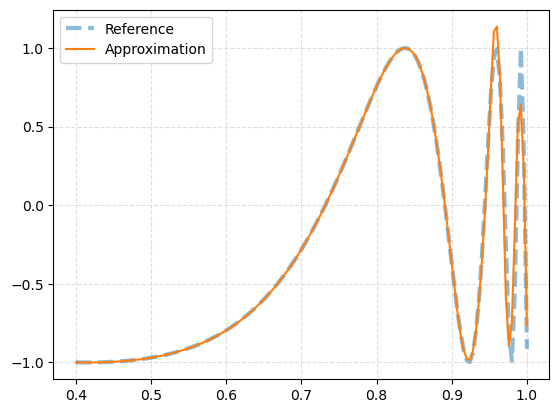

In [138]:
plt.plot(np.linspace(0.4, 1, 151), f(np.linspace(0.4, 1., 151)), label="Reference", alpha=0.5, linewidth=3, ls="--")
plt.plot(np.linspace(0.4,1, 151), aaa(np.linspace(0.4, 1., 151)), label="Approximation")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.show()

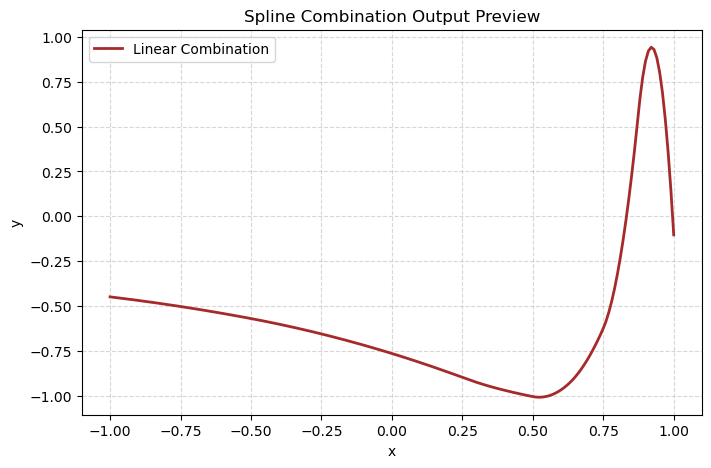

Successfully generated 'linear_combination.txt' for LaTeX!


In [103]:
def b_0_2_taupe(x):
    # domain=-1:-0.5
    mask = (x >= -1.0) & (x <= -0.5)
    return np.where(mask, 4*x**2 + 4*x + 1, 0.0)

def b_1_2_taupe(x):
    # domain=-1:0
    mask = (x >= -1.0) & (x <= 0.0)
    expr = np.where(x < -0.5, -6*x**2 - 8*x - 2, 2*x**2)
    return np.where(mask, expr, 0.0)

def b_2_2_taupe(x):
    res = np.zeros_like(x)
    
    # segment 1: domain=-1:0
    m1 = (x >= -1.0) & (x < 0.0)
    e1 = np.where(x < -0.5, 2*x**2 + 4*x + 2, 
         np.where(x < 0.0, -4*x**2 - 2*x + 0.5, 2*x**2 - 2*x + 0.5))
    res += np.where(m1, e1, 0.0)
    
    # segment 2: domain=0:0.25
    m2 = (x >= 0.0) & (x < 0.25)
    t1 = np.where(x < -0.5, 0, np.where(x < -0.25, 8.0*x**2 + 8.0*x + 2.0, np.where(x < 0.0, -16.0*x**2 - 4.0*x + 0.5, np.where(x < 0.25, 8.0*x**2 - 4.0*x + 0.5, 0))))
    t2 = np.where(x < -0.25, 0, np.where(x < 0.0, 8.0*x**2 + 4.0*x + 0.5, np.where(x < 0.25, -16.0*x**2 + 4.0*x + 0.5, np.where(x < 0.5, 8.0*x**2 - 8.0*x + 2.0, 0))))
    res += np.where(m2, 0.75 * t1 + 0.25 * t2, 0.0)
    
    # segment 3: domain=0.25:0.375
    m3 = (x >= 0.25) & (x < 0.375)
    t3 = np.where(x < 0.0, 0, np.where(x < 0.125, 32.0*x**2, np.where(x < 0.25, -64.0*x**2 + 24.0*x - 1.5, np.where(x < 0.375, 32.0*x**2 - 24.0*x + 4.5, 0))))
    t4 = np.where(x < 0.125, 0, np.where(x < 0.25, 32.0*x**2 - 8.0*x + 0.5, np.where(x < 0.375, -64.0*x**2 + 40.0*x - 5.5, np.where(x < 0.5, 32.0*x**2 - 32.0*x + 8.0, 0))))
    res += np.where(m3, 0.1875 * t3 + 0.0625 * t4, 0.0)
    
    # segment 4: domain=0.375:0.5
    m4 = (x >= 0.375) & (x <= 0.5)
    t5 = np.where(x < 0.125, 0, np.where(x < 0.25, 32.0*x**2 - 8.0*x + 0.5, np.where(x < 0.375, -64.0*x**2 + 40.0*x - 5.5, np.where(x < 0.5, 32.0*x**2 - 32.0*x + 8.0, 0))))
    res += np.where(m4, 0.0625 * t5, 0.0)
    
    return res

def b_3_2_taupe(x):
    res = np.zeros_like(x)
    
    # segment 1: domain=-0.5:0
    m1 = (x >= -0.5) & (x < 0.0)
    e1 = np.where(x < 0, 2*x**2 + 2*x + 0.5, np.where(x < 0.5, -4*x**2 + 2*x + 0.5, 2*x**2 - 4*x + 2))
    res += np.where(m1, e1, 0.0)
    
    # segment 2: domain=0:0.25
    m2 = (x >= 0.0) & (x < 0.25)
    t1 = np.where(x < -0.5, 0, np.where(x < -0.25, 8.0*x**2 + 8.0*x + 2.0, np.where(x < 0.0, -16.0*x**2 - 4.0*x + 0.5, np.where(x < 0.25, 8.0*x**2 - 4.0*x + 0.5, 0))))
    t2 = np.where(x < -0.25, 0, np.where(x < 0.0, 8.0*x**2 + 4.0*x + 0.5, np.where(x < 0.25, -16.0*x**2 + 4.0*x + 0.5, np.where(x < 0.5, 8.0*x**2 - 8.0*x + 2.0, 0))))
    res += np.where(m2, 0.25 * t1 + 0.75 * t2, 0.0)
    
    # segment 3: domain=0.25:0.375
    m3 = (x >= 0.25) & (x < 0.375)
    t3 = np.where(x < 0.0, 0, np.where(x < 0.125, 32.0*x**2, np.where(x < 0.25, -64.0*x**2 + 24.0*x - 1.5, np.where(x < 0.375, 32.0*x**2 - 24.0*x + 4.5, 0))))
    t4 = np.where(x < 0.125, 0, np.where(x < 0.25, 32.0*x**2 - 8.0*x + 0.5, np.where(x < 0.375, -64.0*x**2 + 40.0*x - 5.5, np.where(x < 0.5, 32.0*x**2 - 32.0*x + 8.0, 0))))
    res += np.where(m3, 0.5625 * t3 + 0.1875 * t4, 0.0)
    
    # segment 4: domain=0.375:0.5
    m4 = (x >= 0.375) & (x <= 0.5)
    t5 = np.where(x < 0.125, 0, np.where(x < 0.25, 32.0*x**2 - 8.0*x + 0.5, np.where(x < 0.375, -64.0*x**2 + 40.0*x - 5.5, np.where(x < 0.5, 32.0*x**2 - 32.0*x + 8.0, 0))))
    res += np.where(m4, 0.1875 * t5, 0.0)
    
    return res

def b_6_2_leman(x):
    res = np.zeros_like(x)
    
    # segment 1: domain=0:0.25
    m1 = (x >= 0.0) & (x < 0.25)
    e1 = np.where(x < 0.0, 0, np.where(x < 0.25, 8.0*x**2, np.where(x < 0.5, -16.0*x**2 + 12.0*x - 1.5, np.where(x < 0.75, 8.0*x**2 - 12.0*x + 4.5, 0))))
    res += np.where(m1, e1, 0.0)
    
    # segment 2: domain=0.25:0.375
    m2 = (x >= 0.25) & (x < 0.375)
    t1 = np.where(x < 0.0, 0, np.where(x < 0.125, 32.0*x**2, np.where(x < 0.25, -64.0*x**2 + 24.0*x - 1.5, np.where(x < 0.375, 32.0*x**2 - 24.0*x + 4.5, 0))))
    t2 = np.where(x < 0.125, 0, np.where(x < 0.25, 32.0*x**2 - 8.0*x + 0.5, np.where(x < 0.375, -64.0*x**2 + 40.0*x - 5.5, np.where(x < 0.5, 32.0*x**2 - 32.0*x + 8.0, 0))))
    res += np.where(m2, 0.25 * t1 + 0.75 * t2, 0.0)
    
    # segment 3: domain=0.375:0.5
    m3 = (x >= 0.375) & (x <= 0.5)
    t3 = np.where(x < 0.125, 0, np.where(x < 0.25, 32.0*x**2 - 8.0*x + 0.5, np.where(x < 0.375, -64.0*x**2 + 40.0*x - 5.5, np.where(x < 0.5, 32.0*x**2 - 32.0*x + 8.0, 0))))
    res += np.where(m3, 0.75 * t3, 0.0)
    
    return res

def b_12_2_rouge(x):
    # domain=0.25:0.625
    mask = (x >= 0.25) & (x <= 0.625)
    expr = np.where(x < 0.25, 0, np.where(x < 0.375, 32.0*x**2 - 16.0*x + 2.0, np.where(x < 0.5, -64.0*x**2 + 56.0*x - 11.5, np.where(x < 0.625, 32.0*x**2 - 40.0*x + 12.5, 0))))
    return np.where(mask, expr, 0.0)

def b_13_2_rouge(x):
    # domain=0.375:0.75
    mask = (x >= 0.375) & (x <= 0.75)
    expr = np.where(x < 0.375, 0, np.where(x < 0.5, 32.0*x**2 - 24.0*x + 4.5, np.where(x < 0.625, -64.0*x**2 + 72.0*x - 19.5, np.where(x < 0.75, 32.0*x**2 - 48.0*x + 18.0, 0))))
    return np.where(mask, expr, 0.0)

def b_14_2_rouge(x):
    # domain=0.5:0.875
    mask = (x >= 0.5) & (x <= 0.875)
    expr = np.where(x < 0.5, 0, np.where(x < 0.625, 32.0*x**2 - 32.0*x + 8.0, np.where(x < 0.75, -64.0*x**2 + 88.0*x - 29.5, np.where(x < 0.875, 32.0*x**2 - 56.0*x + 24.5, 0))))
    return np.where(mask, expr, 0.0)

def b_15_2_rouge(x):
    # domain=0.625:1.0
    mask = (x >= 0.625) & (x <= 1.0)
    expr = np.where(x < 0.625, 0, np.where(x < 0.75, 32.0*x**2 - 40.0*x + 12.5, np.where(x < 0.875, -64.0*x**2 + 104.0*x - 41.5, np.where(x < 1.0, 32.0*x**2 - 64.0*x + 32.0, 0))))
    return np.where(mask, expr, 0.0)

def b_16_2_rouge(x):
    # domain=0.75:1.0
    mask = (x >= 0.75) & (x <= 1.0)
    expr = np.where(x < 0.75, 0, np.where(x < 0.875, 32.0*x**2 - 48.0*x + 18.0, np.where(x < 1.0, -96.0*x**2 + 176.0*x - 80.0, 0)))
    return np.where(mask, expr, 0.0)

def b_17_2_rouge(x):
    # domain=0.875:1.0
    mask = (x >= 0.875) & (x <= 1.0)
    expr = np.where(x < 0.875, 0, np.where(x <= 1.0, 64.0*x**2 - 112.0*x + 49.0, 0))
    return np.where(mask, expr, 0.0)

x_vals = np.linspace(-1.0, 1.0, 201)

# List out all 11 basis vectors evaluated over our x_vals array
basis_vectors = [
    b_0_2_taupe(x_vals),   # Index 0: b^(0)_{0,2}
    b_1_2_taupe(x_vals),   # Index 1: b^(0)_{1,2}
    b_2_2_taupe(x_vals),   # Index 2: b^(0)_{2,2}
    b_3_2_taupe(x_vals),   # Index 3: b^(0)_{3,2}
    b_6_2_leman(x_vals),   # Index 4: b^(1)_{6,2}
    b_12_2_rouge(x_vals),  # Index 5: b^(2)_{12,2}
    b_13_2_rouge(x_vals),  # Index 6: b^(2)_{13,2}
    b_14_2_rouge(x_vals),  # Index 7: b^(2)_{14,2}
    b_15_2_rouge(x_vals),  # Index 8: b^(2)_{15,2}
    b_16_2_rouge(x_vals),  # Index 9: b^(2)_{16,2}
    b_17_2_rouge(x_vals)   # Index 10: b^(2)_{17,2}
]

coefficients = [
    0.0,  # weight for b^(0)_{0,2}
    0.0,  # weight for b^(0)_{1,2}
    0.0,  # weight for b^(0)_{2,2}
    1.0,  # weight for b^(0)_{3,2}
    0.0,  # weight for b^(1)_{6,2}
    0.0,  # weight for b^(2)_{12,2}
    0.0,  # weight for b^(2)_{13,2}
    0.0,  # weight for b^(2)_{14,2}
    0.0,  # weight for b^(2)_{15,2}
    0.0,  # weight for b^(2)_{16,2}
    0.0   # weight for b^(2)_{17,2}
]

y_combination = np.zeros_like(x_vals)
for coeff, basis in zip(c, basis_vectors):
    y_combination += coeff * basis

plt.figure(figsize=(8, 5))
plt.plot(x_vals, y_combination, label="Linear Combination", color="brown", lw=2)
# plt.plot(x_vals, np.sin(1./(x_vals-1.15)), label="Ground truth")
plt.grid(True, linestyle="--", alpha=0.5)
plt.title("Spline Combination Output Preview")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

data_matrix = np.column_stack((x_vals, y_combination))
np.savetxt("linear_combination.txt", data_matrix, header="x y", comments="")
print("Successfully generated 'linear_combination.txt' for LaTeX!")

In [ ]:
# fig, axs = plt.subplots(len(ps), 1)
# fig.tight_layout()
# for i, ax in enumerate(axs):
#     ax.semilogy(grid_size[i], l2_errors[i], label=ps[i], marker='x')
#     #ax.set_xticks(grid_size[i])
#     #ax.set_yticks(np.round(l2_errors, 6)[i])
# plt.legend()
# plt.show()

In [ ]:
import itertools
ps = [3,1]  # Degrees for x and y
#knots_x = np.array([-2., -2., -2., -1.5, -1., -0.5, 0.,0., 0.5,0.5, 1., 1.5, 2., 2., 2.])
#knots_y = np.array([-1., -1., -1., -0.5,-0.5, 0.,0., 0.5, 1.,1., 1.5,1.5, 2., 2.5, 2.5, 2.5])
knots_x = np.array([-1, -1, -1, -0.5, 0,0, 0.5, 1, 1, 1], dtype=np.float64)
knots_y = np.array([-2, -2, -2, -1, 0,0, 1, 2, 2, 2], dtype=np.float64)
knots_x = refine(knots_x, ps[0], 1)
knots_y = refine(knots_y, ps[1], 1)
#knots_x = np.array([-1., -1., -1, 0, 1, 1, 1], dtype=np.float64)
#knots_y = np.array([0,0., 0, 1, 1, 1], dtype=np.float64)
knots = [knots_x, knots_y]
f = lambda x, y: y+0.31*x**2 - x*y - 0.9

hs = HierarchicalSpace(knots, ps)
#hs.refine([0,1,2,3,4,7,8,11,12], 0)
#hs.refine([12,13,26,27], 1, refine_neighbours=True)
hs.refine_in_rectangle(np.array([[0,0.25], [-0.75, -0.5]]),1, refine_neighbours=True)
hs.refine_in_rectangle(np.array([[0., 0.25], [-0.75, -0.5]]), 2, refine_neighbours=True)
hs.refine_in_rectangle(np.array([[0., 0.25], [-1, -0.874]]),3, refine_neighbours=True)
#hs.refine_in_rectangle(np.array([[-2., 2.], [2., 2.5]]), 0, refine_neighbours=True)
#hs.refine_in_rectangle(np.array([[1.5, 2], [-1, 2.5]]), 0, refine_neighbours=True)
#hs.refine_in_rectangle(np.array([[-2, -1.5], [-1, 2.5]]), 0, refine_neighbours=True)
#hs.refine_in_rectangle(np.array([[-2., 2.], [-1., -0.5]]), 0, refine_neighbours=True)
hs.hmesh.plot_cells()
dof_map, _ = hs.build_global_dof_map()
#print(f"dofmap = {dof_map}\n")
num_dofs = 0
for i in range(hs.nlevels):
    num_dofs += len(hs.truly_active[i])

M_global = np.zeros((num_dofs, num_dofs))
F_global = np.zeros(num_dofs)

# Quadrature Setup (Standard Gauss-Legendre for each dimension)
q_pts_x, q_wts_x = np.polynomial.legendre.leggauss(ps[0] + 1)
q_pts_y, q_wts_y = np.polynomial.legendre.leggauss(ps[1] + 1)

for l in range(hs.nlevels):
    # mesh_shape helps us unravel the flat element index into (i, j) grid indices
    nx, ny = hs.hmesh.meshes_shape[l]
    
    for element in hs.hmesh.aelem_level[l]:
        # Map flat element index to 2D grid indices
        idx_x, idx_y = np.unravel_index(element, (nx, ny))
        #print(f"level={l}, element={element}, idx={idx_x}, idy={idx_y}")
        
        # Get boundaries for the current element
        x_min, x_max = hs.hmesh.one_d_indices[l][0][idx_x], hs.hmesh.one_d_indices[l][0][idx_x + 1]
        y_min, y_max = hs.hmesh.one_d_indices[l][1][idx_y], hs.hmesh.one_d_indices[l][1][idx_y + 1]
        
        # Compute Jacobian (Area of the physical cell / Area of reference [-1, 1]^2)
        det_J = ((x_max - x_min) / 2.0) * ((y_max - y_min) / 2.0)
        
        # Local extraction operator (Truncation)
        if element>1:
            pass
        M_loc = hs.local_multi_level_extraction_operator(element_idx=element, element_level=l, l=l)
        
        # Local basis size for tensor product: (px+1)*(py+1)
        local_size = (ps[0] + 1) * (ps[1] + 1)
        M_b = np.zeros((local_size, local_size))
        F_b = np.zeros(local_size)
        #print(f"hs.level_spaces[{l}].spaces[0].cell_to_basis_indices([{idx_x}])[0] = {hs.level_spaces[l].spaces[0].cell_to_basis_indices([idx_x])[0]}")
        #print(f"hs.level_spaces[{l}].spaces[1].cell_to_basis_indices([{idx_y}])[0] = {hs.level_spaces[l].spaces[1].cell_to_basis_indices([idx_y])[0]}")
        
        # Identify which level-l functions are supported on this element
        # (Standard B-splines at level l that form the tensor product basis)
        #active_fcts = hs.level_spaces[l].cell_to_basis([element])
        #print(f"level= {l}, element = {element}, active_fcts = {active_fcts}")
        
        # 2D Quadrature Loop
        #print(f"l={l}, x_min={x_min}, x_max={x_max}, y_min={y_min}, y_max={y_max}")
        for (qp_x, qw_x), (qp_y, qw_y) in itertools.product(zip(q_pts_x, q_wts_x), zip(q_pts_y, q_wts_y)):
            # Map quadrature points to physical element
            x_q = x_min + (qp_x + 1.) / 2. * (x_max - x_min)
            y_q = y_min + (qp_y + 1.) / 2. * (y_max - y_min)
            
            # Evaluate 1D basis functions
            # Note: Depending on your BSpline.design_matrix wrapper, 
            # you may need to evaluate x and y separately and take the Kronecker product.
            b_vals_x = BSpline.design_matrix(x_q, hs.level_spaces[l].spaces[0].knots, ps[0])[:, hs.level_spaces[l].spaces[0].cell_to_basis_indices([idx_x])[0]].toarray().ravel()
            b_vals_y = BSpline.design_matrix(y_q, hs.level_spaces[l].spaces[1].knots, ps[1])[:, hs.level_spaces[l].spaces[1].cell_to_basis_indices([idx_y])[0]].toarray().ravel()
            
            # Tensor product basis values: B(x,y) = N(x) * M(y)
            b_vals_2d = np.kron(b_vals_x, b_vals_y) # Watch the order (x then y) based on dof_map
            
            weight = qw_x * qw_y * det_J
            M_b += weight * np.outer(b_vals_2d, b_vals_2d)
            F_b += weight * b_vals_2d * f(x_q, y_q)
            
        # Apply truncation/refinement transformation
        #print(f"level={l}, element={element}, F_b=\n{np.round(F_b, 4)}\n")
        M_e = M_loc @ M_b @ M_loc.T
        F_e = M_loc @ F_b
        if element==9:
            pass
            #print(f"level={l}, element={element}, M_loc = {np.round(M_loc.toarray(), 2)}")
        if not np.allclose(np.ones(M_loc.shape[1]), M_loc.sum(axis=0)):
            print(M_loc.sum(axis=0))
        
        # Global Assembly
        global_indices = hs.element_global_indices(dof_map=dof_map, element_level=l, element_idx=element)
        #print(f"l={l}, element={element}, global_indices={global_indices}")
        for i, I in enumerate(global_indices):
            F_global[I] += F_e[i]
            for j, J in enumerate(global_indices):
                M_global[I, J] += M_e[i, j]

# Solve: c = M \ F
c = np.linalg.solve(M_global, F_global)

In [ ]:
from scipy.integrate import nquad
def f_squared(x,y):
    return f(x,y)**2

domain_bounds = [[knots_x[0], knots_x[-1]], [knots_y[0], knots_y[-1]]]
integral_f2, _ = nquad(f_squared, domain_bounds)
print(integral_f2)
print(abs(integral_f2-c@F_global))

In [ ]:
import numpy as np
from scipy.integrate import nquad
sigma = 0.4
def ricker(x,y):
    h = lambda x,y: 1./(np.pi*sigma**4)*(1.-0.5*((x**2+y**2)/sigma**2)) * np.exp(-(x**2+y**2)/(2.*sigma**2))
    return h(x,y)**2
def three_exps(x,y):
    g= lambda x,y: 2./(3.*np.exp(np.sqrt((10.*x-3.)**2 + (10*y-3)**2))) + 2./(3.*np.exp(np.sqrt((10.*x+3.)**2 + (10*y+3)**2))) + 2./(3.*np.exp(np.sqrt((10.*x)**2 + (10*y)**2)))
    return g(x,y)**2
domain_bounds = [[-1., 1.], [-1., 1.]]
nquad(ricker, domain_bounds)


In [ ]:
print(c@F_global)

In [ ]:
# knots_x=[-0.5,0,0.5,1]
# knots_y=[0,0,0.5,1]
# def fbb(x,y):
#     return f(x,y)*BSpline.basis_element(knots_x, extrapolate=False)(x)*BSpline.basis_element(knots_y, extrapolate=False)(y)
# integral_fbb, _ = nquad(fbb, [[0.5, 1.], [0.5,1.]])
# print(integral_fbb)

In [ ]:
print(f" l2 error = {np.sqrt(np.abs(c.dot(F_global)-integral_f2)):.4e}")